# HW13 – Токенизация, инференс BERT и fine-tuning для классификации текста

**Датасет:** `emotion` (6 классов: sadness, joy, love, anger, fear, surprise)  
**Модель:** `distilbert-base-uncased`

## 1. Импорты, seed и среда

In [1]:
import random
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# --- Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Device ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# --- Artifacts dir ---
ARTIFACTS_DIR = 'artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# --- Versions ---
import transformers, datasets as ds_lib, sklearn
print(f'torch:        {torch.__version__}')
print(f'transformers: {transformers.__version__}')
print(f'datasets:     {ds_lib.__version__}')
print(f'sklearn:      {sklearn.__version__}')

Device: cuda
torch:        2.11.0+cu128
transformers: 5.5.0
datasets:     4.8.4
sklearn:      1.8.0


## 2. Данные и первичный анализ

In [2]:
ds = load_dataset('emotion')
print(ds)

label_names = ds['train'].features['label'].names
print(f'\nКлассы ({len(label_names)}): {label_names}')
print(f'train:      {len(ds["train"])} примеров')
print(f'validation: {len(ds["validation"])} примеров')
print(f'test:       {len(ds["test"])} примеров')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
train:      16000 примеров
validation: 2000 примеров
test:       2000 примеров


In [3]:
# 5 примеров
df_sample = pd.DataFrame(ds['train'].select(range(5)))
df_sample['label_name'] = df_sample['label'].map(lambda x: label_names[x])
print('Примеры из train:')
print(df_sample[['text', 'label_name']].to_string(index=False))

# Распределение классов
from collections import Counter
counts = Counter(ds['train']['label'])
print('\nРаспределение классов в train:')
for idx, cnt in sorted(counts.items()):
    print(f'  {label_names[idx]:10s}: {cnt}')

Примеры из train:
                                                                                                        text label_name
                                                                                     i didnt feel humiliated    sadness
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake    sadness
                                                            im grabbing a minute to post i feel greedy wrong      anger
                i am ever feeling nostalgic about the fireplace i will know that it is still on the property       love
                                                                                        i am feeling grouchy      anger

Распределение классов в train:
  sadness   : 4666
  joy       : 5362
  love      : 1304
  anger     : 2159
  fear      : 1937
  surprise  : 572


**Что классифицируется:** короткие твиты на английском языке по 6 эмоциям: sadness, joy, love, anger, fear, surprise. Датасет несбалансирован — joy и sadness встречаются значительно чаще остальных классов.

## 3. Токенизация

In [4]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = [ds['train'][i]['text'] for i in range(5)]

print(f'Special tokens: CLS={tokenizer.cls_token!r}, SEP={tokenizer.sep_token!r}, PAD={tokenizer.pad_token!r}')
print(f'Vocab size: {tokenizer.vocab_size}\n')

for i, text in enumerate(sample_texts):
    enc = tokenizer(text, truncation=True, max_length=64)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
    print(f'[{i}] text:           {text[:70]}')
    print(f'     tokens:         {tokens}')
    print(f'     input_ids:      {enc["input_ids"]}')
    print(f'     attention_mask: {enc["attention_mask"]}')
    print()

Special tokens: CLS='[CLS]', SEP='[SEP]', PAD='[PAD]'
Vocab size: 30522

[0] text:           i didnt feel humiliated
     tokens:         ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
     input_ids:      [101, 1045, 2134, 2102, 2514, 26608, 102]
     attention_mask: [1, 1, 1, 1, 1, 1, 1]

[1] text:           i can go from feeling so hopeless to so damned hopeful just from being
     tokens:         ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
     input_ids:      [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
     attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

[2] text:           im grabbing a minute to post i feel greedy wrong
     tokens:         ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to',

In [5]:
# Пример padding и truncation на батче
batch = tokenizer(
    sample_texts[:3],
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)
print('Batch input_ids shape:      ', batch['input_ids'].shape)
print('Batch attention_mask shape: ', batch['attention_mask'].shape)
print('\ninput_ids (padded):')
print(batch['input_ids'])
print('\nattention_mask (0 = PAD):')
print(batch['attention_mask'])

Batch input_ids shape:       torch.Size([3, 23])
Batch attention_mask shape:  torch.Size([3, 23])

input_ids (padded):
tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0],
        [  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
          9636, 17772,  2074,  2013,  2108,  2105,  2619,  2040, 14977,  1998,
          2003,  8300,   102],
        [  101, 10047,  9775,  1037,  3371,  2000,  2695,  1045,  2514, 20505,
          3308,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0]])

attention_mask (0 = PAD):
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


## 4. Инференс готовой pretrained модели

In [6]:
# Готовая модель: sentiment (SST-2, 2 класса)
sentiment_pipe = pipeline(
    'text-classification',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0 if DEVICE == 'cuda' else -1
)

test_texts_5 = [ds['test'][i]['text'] for i in range(5)]
test_labels_5 = [label_names[ds['test'][i]['label']] for i in range(5)]

results = sentiment_pipe(test_texts_5)

print('Инференс готовой SST-2 модели на примерах из emotion/test:')
print(f'{"Text":<55} {"True":^10} {"Predicted":^12} {"Score"}')
print('-' * 90)
for text, true_lbl, res in zip(test_texts_5, test_labels_5, results):
    print(f'{text[:53]:<55} {true_lbl:^10} {res["label"]:^12} {res["score"]:.3f}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Инференс готовой SST-2 модели на примерах из emotion/test:
Text                                                       True     Predicted   Score
------------------------------------------------------------------------------------------
im feeling rather rotten so im not very ambitious rig    sadness     NEGATIVE   1.000
im updating my blog because i feel shitty                sadness     NEGATIVE   0.999
i never make her separate from me because i don t eve    sadness     POSITIVE   0.999
i left with my bouquet of red and yellow tulips under      joy       POSITIVE   0.987
i was feeling a little vain when i did this one          sadness     NEGATIVE   1.000


**Вывод:** Готовая SST-2 модель предсказывает только POSITIVE/NEGATIVE, тогда как задача — 6 эмоций. Это несовпадение задач: модель не подходит напрямую и требует fine-tuning под конкретные классы.

## 5. Fine-tuning для классификации текста

In [7]:
MAX_LENGTH = 128
NUM_LABELS = len(label_names)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH, padding='max_length')

tokenized = ds.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print('Токенизация завершена.')
print('Пример ключей:', list(tokenized['train'][0].keys()))

Токенизация завершена.
Пример ключей: ['labels', 'input_ids', 'attention_mask']


In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: l for i, l in enumerate(label_names)},
    label2id={l: i for i, l in enumerate(label_names)},
)
model.to(DEVICE)
print(f'Модель: {MODEL_NAME}')
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель: distilbert-base-uncased
Параметров: 66,958,086


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='./artifacts/tmp_trainer',
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    fp16=(DEVICE == 'cuda'),
    dataloader_num_workers=0,
    seed=SEED,
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    compute_metrics=compute_metrics,
)

print('Начинаем обучение...')
train_result = trainer.train()
print('Обучение завершено.')
print(train_result.metrics)

Начинаем обучение...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.360885,0.280991,0.913500,0.880835
2,0.204197,0.188378,0.924500,0.898379
3,0.158810,0.175871,0.929000,0.903652


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Обучение завершено.
{'train_runtime': 62.2187, 'train_samples_per_second': 771.472, 'train_steps_per_second': 12.054, 'total_flos': 1589722177536000.0, 'train_loss': 0.39458786328633627, 'epoch': 3.0}


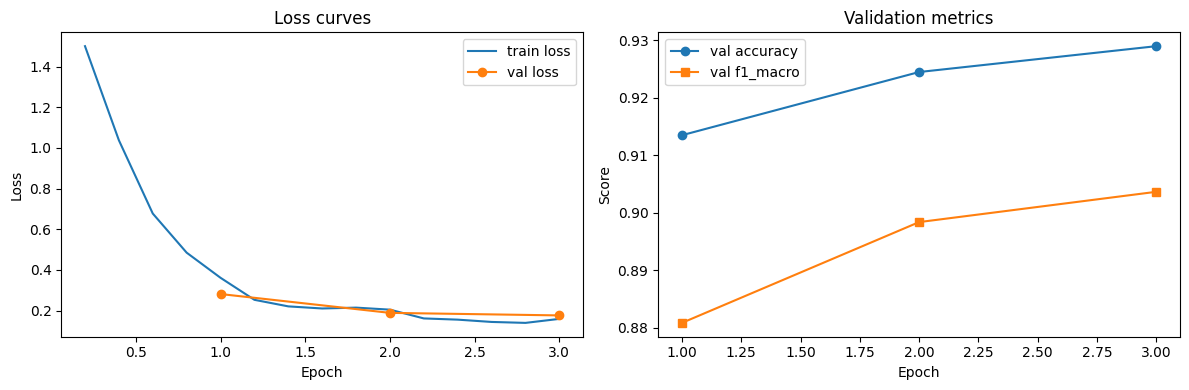

Сохранено: artifacts/training_curves.png


In [10]:
# Кривые обучения
log_history = trainer.state.log_history
train_losses = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_entries = [(e['epoch'], e['eval_loss'], e['eval_accuracy'], e['eval_f1_macro'])
                for e in log_history if 'eval_loss' in e]

if train_losses and eval_entries:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot([x[0] for x in train_losses], [x[1] for x in train_losses], label='train loss')
    axes[0].plot([x[0] for x in eval_entries], [x[1] for x in eval_entries], marker='o', label='val loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].set_title('Loss curves')
    axes[1].plot([x[0] for x in eval_entries], [x[2] for x in eval_entries], marker='o', label='val accuracy')
    axes[1].plot([x[0] for x in eval_entries], [x[3] for x in eval_entries], marker='s', label='val f1_macro')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].legend(); axes[1].set_title('Validation metrics')
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS_DIR, 'training_curves.png'), dpi=100)
    plt.show()
    print('Сохранено: artifacts/training_curves.png')

## 6. Оценка качества и анализ ошибок

In [11]:
# Финальная оценка на test (один раз)
test_output = trainer.predict(tokenized['test'])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_labels_arr = test_output.label_ids

test_acc = accuracy_score(test_labels_arr, test_preds)
test_f1  = f1_score(test_labels_arr, test_preds, average='macro')

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1 Macro : {test_f1:.4f}')

Test Accuracy : 0.9240
Test F1 Macro : 0.8803


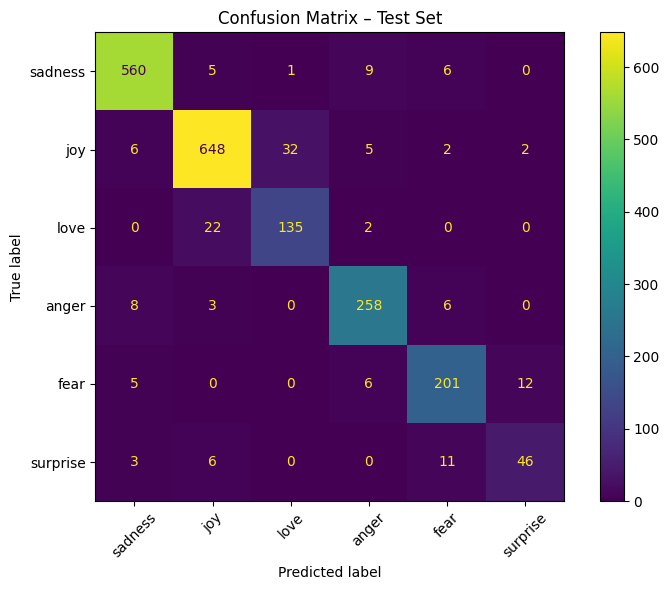

Сохранено: artifacts/confusion_matrix.png


In [12]:
# Матрица ошибок
cm = confusion_matrix(test_labels_arr, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'confusion_matrix.png'), dpi=100)
plt.show()
print('Сохранено: artifacts/confusion_matrix.png')

In [13]:
# Сохраняем все предсказания + confidence
probs = torch.softmax(torch.tensor(test_output.predictions, dtype=torch.float32), dim=-1).numpy()
confidences = probs.max(axis=-1)

df_preds = pd.DataFrame({
    'text':       ds['test']['text'],
    'true_label': [label_names[l] for l in ds['test']['label']],
    'pred_label': [label_names[p] for p in test_preds],
    'confidence': confidences,
})

csv_path = os.path.join(ARTIFACTS_DIR, 'sample_predictions.csv')
df_preds.to_csv(csv_path, index=False)
print(f'Сохранено: {csv_path} ({len(df_preds)} строк)')

print('\n10 случайных примеров предсказаний:')
print(df_preds.sample(10, random_state=SEED)[['text', 'true_label', 'pred_label', 'confidence']].to_string(index=False))

Сохранено: artifacts\sample_predictions.csv (2000 строк)

10 случайных примеров предсказаний:
                                                                                                                                                                                                                                          text true_label pred_label  confidence
i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter between us luckily for us both i liked the everblight and he liked the circle maybe a tad to much so it all worked out well    sadness    sadness    0.988367
                                                                                                                                                                                i could feel his breath on me and smell the sweet scent of him        joy       love    0.654297
                                                                                       

In [14]:
# Анализ ошибок
df_errors = df_preds[df_preds['true_label'] != df_preds['pred_label']].copy()
print(f'Всего ошибок: {len(df_errors)} из {len(df_preds)} ({len(df_errors)/len(df_preds)*100:.1f}%)')
print('\n7 примеров ошибок:')
print(df_errors.sample(min(7, len(df_errors)), random_state=SEED)[['text', 'true_label', 'pred_label', 'confidence']].to_string(index=False))

Всего ошибок: 152 из 2000 (7.6%)

7 примеров ошибок:
                                                                                        text true_label pred_label  confidence
                          i chant the invocation and feel his force supporting me as i teach        joy       love    0.550767
                       im polyamorous something im starting to feel truly accepted for being       love        joy    0.646874
                                                  at a party i met a girl who drew me to her      anger       fear    0.494199
i feel affirmed gracious sensuous and will have less self doubt when a href http generations       love        joy    0.975154
                          i did a body scan and realized that everything was feeling amazing   surprise        joy    0.569935
                                                   i need a break or im feeling stressed out      anger    sadness    0.820533
                              i could feel his breath on m

In [15]:
print('=' * 45)
print('ИТОГ:')
print(f'  Test Accuracy : {test_acc:.4f}')
print(f'  Test F1 Macro : {test_f1:.4f}')
print('=' * 45)

ИТОГ:
  Test Accuracy : 0.9240
  Test F1 Macro : 0.8803
